# Exploring ways to model "Who Pays" distribution more accurately

The Problem:
- France's insurance system decides based on a relative distruction basis which actor (farmer, government, insurance) covers how much of the damage.
- Until now we have fed the expected annual impact (EAI) into a function to estimate who has to pay how much. We realized however that this is not accuracte at all as the EAI has to be above the threshold of 20% so that the computation makes it seem as if the insurance is paying anything at all. The idea of insurance though is not to cover expected big damages but extreme events that do not happen like this every year.

What we would need to do, to make the estimate accurate:

- Compute every how many years the 20% and 50% boundary would be triggered (per hazard or maybe there is a way to make a single hazard object)
- Frequency * Who Pays * ? (It doesn’t make sense to multiply by EAI here because more of the damage will be in the upper categories)

How to actually do:
- Hazard * Impact Function -> Relative Impacts per Pixel (how does an impact object look like?
- Make a new Hazard object out of the impact object that just mixes the hazards (all relative impacts)
- Compute Yearly Impacts (here we would need to implement a multiplication of the relative impacts.)
- Then use the years to find out how often certain damages happen

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## Imports

import sys
sys.path.append("..") # Adds the project root to the path

---

# Trying to Create Combined Hazard Object

In [3]:
from src.data_hazard import get_TC, get_TP

hazard_dict_TC = get_TC()
hazard_dict_TP = get_TP()

In [4]:
from src.data_exposure import get_exposure
from climada.entity import Exposures
import climada.util.lines_polys_handler as u_lp
from copy import deepcopy

exposure_poly = get_exposure(["TC", "TP", "MG"])

exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=10000,      # TODO: Go back down to KM for Flood and Hail
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

## Poly -> Eigen Raster Exposure
exposure_pnt_eigen_gdf = deepcopy(exposure_pnt.gdf)
exposure_pnt_eigen_gdf["value"] = 1
exposure_pnt_eigen = Exposures(exposure_pnt_eigen_gdf)

2026-05-20 13:39:27,882 - climada.util.lines_polys_handler - WARNING - Polygon smaller than resolution. Setting a representative point.
2026-05-20 13:39:27,925 - climada.util.lines_polys_handler - WARNING - Polygon smaller than resolution. Setting a representative point.


In [5]:
from climada.engine import ImpactCalc

impact_TC = ImpactCalc(
        exposure_pnt_eigen,
        impfset=hazard_dict_TC["impf_set"],
        hazard=hazard_dict_TC["hazard"]
    ).impact(save_mat=True)

impact_TC

In [6]:
from climada.engine import ImpactCalc

impact_TP = ImpactCalc(
        exposure_pnt_eigen,
        impfset=hazard_dict_TP["impf_set"],
        hazard=hazard_dict_TP["hazard"]
    ).impact(save_mat=True)

impact_TP

In [7]:
## Looking at what the Impact Matrix looks like
impact_TC.imp_mat[:10, :10].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [8]:
## Testing how to extreact event's frequency
impact_TC.frequency

array([0.02857143, 0.02857143, 0.02857143, ..., 0.02857143, 0.02857143,
       0.02857143])

In [9]:
impact_TC.coord_exp

array([[45.74004114,  5.53906526],
       [45.74004114,  5.62889678],
       [45.74004114,  5.71872831],
       ...,
       [49.18252671,  1.69862763],
       [49.18252671,  2.05795374],
       [49.18252671,  2.14778527]])

## Build new Hazard

Idea: Building synthetic hazard with relative intensities from the indivitual impact matrices

In [10]:
from scipy.sparse import vstack
import numpy as np

imp_mat_stacked = vstack([
    impact_TC.imp_mat,
    impact_TP.imp_mat
])

freq_stacked = np.concatenate([
    impact_TC.frequency,
    impact_TP.frequency,
])

In [11]:
from climada.hazard.centroids import Centroids

coords = impact_TC.coord_exp

centroids = Centroids(
    lat=coords[:, 0],
    lon=coords[:, 1]
)

In [12]:
fraction_mat = imp_mat_stacked.copy()
fraction_mat.data[:] = 1.0

In [13]:
from climada.hazard import Hazard

n_events, n_points = imp_mat_stacked.shape

hazard_combined = Hazard(haz_type="MG")

hazard_combined.centroids = centroids

hazard_combined.intensity = imp_mat_stacked
hazard_combined.frequency = freq_stacked
hazard_combined.fraction = fraction_mat

## Adding Infos
hazard_combined.event_id = np.arange(1, n_events + 1)
hazard_combined.event_name = np.array([f"event_{i}" for i in hazard_combined.event_id])
hazard_combined.date = np.arange(n_events).astype("datetime64[D]")


# --- Metadata ---
hazard_combined.units = "rel"
hazard_combined.tag = {
    "description": "Merged Events into Relative Impacts"
}

hazard_combined

## Hazard -> Impact

> (via Eigenexposure + Eigenimpact)

In [14]:
from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet

impf_eigen = ImpactFunc(
    id=1,
    name = "Total Precipitation Impact Function (ChatGPT)",
    intensity_unit="mm",
    haz_type=hazard_combined.haz_type,
    intensity=np.array([0, 1]),
    mdd=np.array([0, 1]),
    paa = np.ones(2)
)

impf_eigen_set = ImpactFuncSet([impf_eigen])

In [15]:
impact_combined = ImpactCalc(
        exposures=exposure_pnt_eigen,
        impfset=impf_eigen_set,
        hazard=hazard_combined
    ).impact(save_mat=True)

impact_combined

---

# Sampling Years to Aggregate Impact

In [16]:
## Sampling a Yearset -> Computing Yearly Impacts

import numpy as np
import climada.util.yearsets as yearsets
from climada.engine import Impact

sampled_years = list(range(1900, 2000))

# direct computation
yimp, sampling_vect = yearsets.impact_yearset(
    impact_combined, sampled_years, correction_fac=False,
)

2026-05-20 13:39:30,233 - climada.util.yearsets - WARNING - The frequencies of the different events are not equal. This can lead to distorted sampling if the frequencies vary significantly. To avoid this, please set `with_replacement=True` to sample with replacement instead.


In [17]:
## Manually creating imp_mat for Yearset

import scipy.sparse as sp

sparse_matrix = impact_combined.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sp.csr_matrix(1.-(1.-sparse_matrix[indices, :].toarray()).prod(axis=0))
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yimp.imp_mat = summed_matrix

yimp.coord_exp = impact_combined.coord_exp
yimp.at_event, yimp.eai_exp, yimp.aai_agg = (
    ImpactCalc.risk_metrics(yimp.imp_mat, yimp.frequency)
)

array([<GeoAxes: title={'center': 'Impact: 0.2 USD'}>,
       <GeoAxes: title={'center': 'Impact: 0.5 USD'}>], dtype=object)

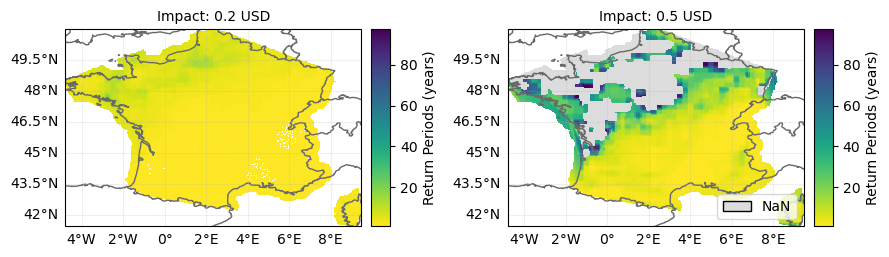

In [ ]:
## Computing Local Return Periods for Tresholds

from climada.util.plot import plot_from_gdf

threshold_values = [.20, .50]
gdf_rp, title, cols = yimp.local_return_period(threshold_values, method="extrapolate_constant")

In [ ]:
plot_from_gdf(gdf_rp, title, cols)

---

# Yearsets -> Who Pays What?

1. Compute who pays what for each year in the Yearset
2. Average over all Samples Years (as all years have the same frequencies this works)
3. Multiply with relative Exposure
4. Aggregate to Departements

-> Expected Annual Area Payed by Actor

In [20]:
coo = yimp.imp_mat.tocoo()

damage = coo.data
event_idx = coo.row
loc_idx = coo.col

In [21]:
exposure = exposure_pnt.gdf["value"]
exposure_loc = exposure.iloc[loc_idx].values

insurance_takeup = exposure_pnt.gdf["insurance"]
insured = insurance_takeup.iloc[loc_idx].values

In [ ]:
## Who Pays neds to be updated because we are now working with a sparse matrix

cond_high = damage >= 0.5
cond_mid  = (damage >= 0.2) & (damage < 0.5)
cond_low  = damage < 0.2

F = np.zeros_like(damage)
I = np.zeros_like(damage)
G = np.zeros_like(damage)

# Farmer
F = (
    cond_high * ((1 - insured) * 0.65) +
    cond_mid  * ((1 - insured) * 1.0) +
    cond_low  * 1.0
)

# Insurance
I = (
    cond_high * (insured * 0.1) +
    cond_mid  * (insured * 1.0)
)

# Government
G = (
    cond_high * (insured * 0.9 + (1 - insured) * 0.35)
)

In [45]:
## Computing Total Impact
n_years = yimp.imp_mat.shape[0]

E_F = np.nansum(damage * exposure_loc * F) / n_years
E_I = np.nansum(damage * exposure_loc * I) / n_years
E_G = np.nansum(damage * exposure_loc * G) / n_years

In [46]:
print(f"{E_F = }")
print(f"{E_I = }")
print(f"{E_G = }")

E_F = 188.550984368121
E_I = 53.59310489600223
E_G = 41.94378984529517


In [47]:
## Sanity Check
## -> Should be the same

print(f"{E_F + E_I + E_G = }")
print(f"{np.nansum(damage * exposure_loc) / n_years = }")

E_F + E_I + E_G = 284.0878791094184
np.nansum(damage * exposure_loc) / n_years = 284.1233645655043


In [54]:
n_years = yimp.imp_mat.shape[0]

F_relative = np.bincount(
    loc_idx,
    weights=damage * exposure_loc * F,
    minlength=yimp.imp_mat.shape[1]
) / n_years

I_relative = np.bincount(
    loc_idx,
    weights=damage * exposure_loc * I,
    minlength=yimp.imp_mat.shape[1]
) / n_years

G_relative = np.bincount(
    loc_idx,
    weights=damage * exposure_loc * G,
    minlength=yimp.imp_mat.shape[1]
) / n_years

In [55]:
pnt_gdf = exposure_pnt.gdf.copy()

pnt_gdf["F_relative"] = F_relative
pnt_gdf["I_relative"] = I_relative
pnt_gdf["G_relative"] = G_relative

In [57]:
from src.helpers import agg_to_departement

dep_result = agg_to_departement(
            pnt_gdf=pnt_gdf,
            value_cols=["value", "insurance", "F_relative", "I_relative", "G_relative"],
            agg_func="mean"
        )

In [58]:
result = dep_result[['F_relative', 'I_relative', 'G_relative']].mul(
    dep_result['area'], axis=0
)

result.columns = ['F_area', 'I_area', 'G_area']

dep_result = dep_result.join(result)

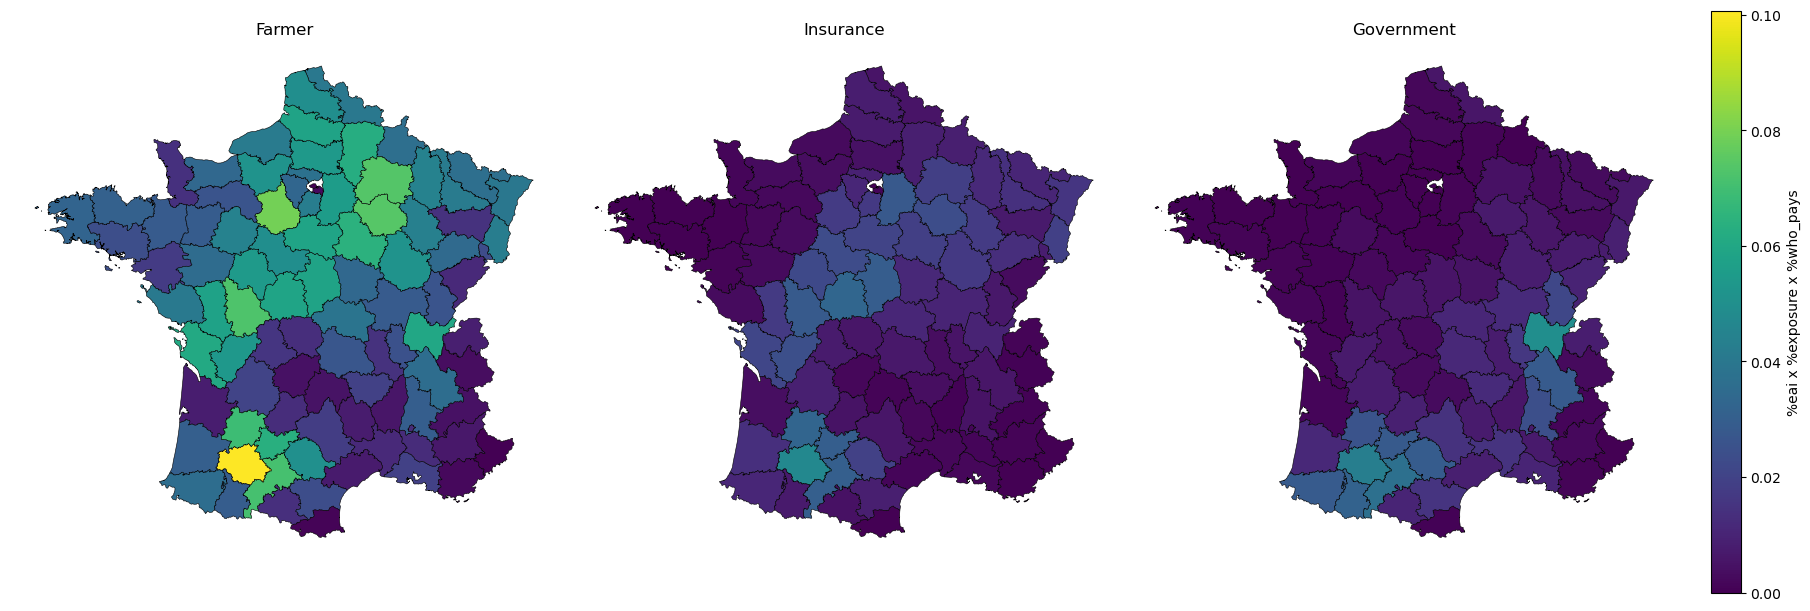

In [60]:
## Plotting
## Who Pays Damaged Area per Deparetement
## Percentage Payed x Damaged Area

results = dep_result

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F_relative", "I_relative", "G_relative"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
vmin = results[cols].min().min()
vmax = results[cols].max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    results.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("%eai x %exposure x %who_pays")

plt.show()

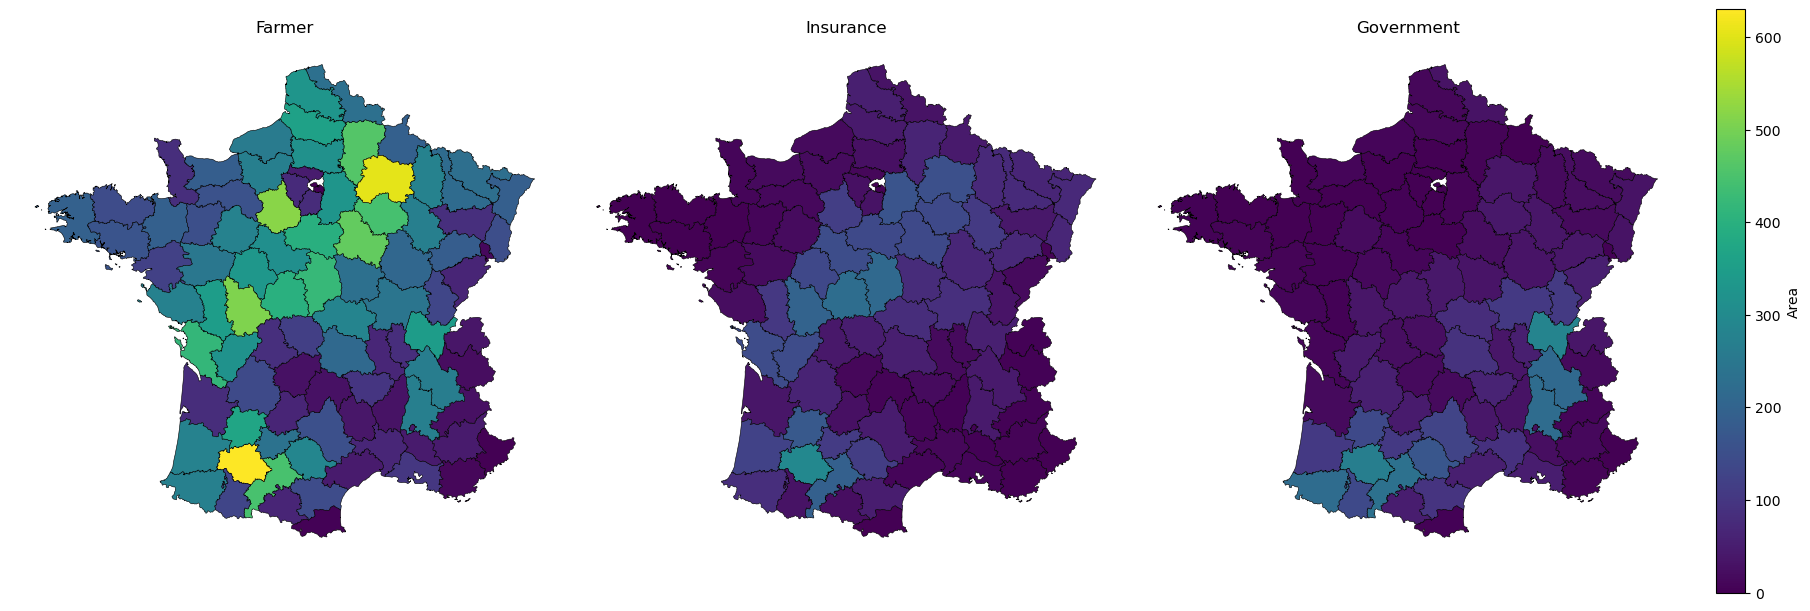

In [61]:
## Plotting
## Who Pays Damaged Area per Deparetement
## Percentage Payed x Damaged Area

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F_area", "I_area", "G_area"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
vmin = results[cols].min().min()
vmax = results[cols].max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    results.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("Area")

plt.show()

## TODOS

- Add Exposure only later
- Understand Computation
- Think about how to integrate in pipeline

## Open Questions

Once I know how often the threshold is crossed, I need to know how much of the damage is occuring. Or is that the same? or the integral of how often times how much of the damage is in there?

How are events sampled into years? Do I actually get more when I concatenate the different hazards?


## Discussion with Valentin

- Concatenating Events: Does it yield the result I want/expect? (Other option: Multiply yearsets) -> We are pretty sure that yes

